In [204]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:


nx, ny = 9, 7

nx_reduce, ny_reduce = 7, 5

Nx, Ny = 2**nx, 2**ny

Nx_reduce, Ny_reduce = 2**nx_reduce, 2**ny_reduce

Lx, Ly = 200.0, 50.0

dx, dy = Lx / Nx, Ly / Ny

x = (np.arange(Nx) - Nx//2) * dx
y = (np.arange(Ny) - Ny//2) * dy

X, Y = np.meshgrid(x, y, indexing='ij')


dt = 0.01

t = 70

steps = int(np.round(t / dt))

kx = 2.0 * np.pi * np.fft.fftfreq(Nx, d=dx)
ky = 2.0 * np.pi * np.fft.fftfreq(Ny, d=dy)
KX, KY = np.meshgrid(kx, ky, indexing='ij')
K2 = KX**2 + KY**2

L_half = np.exp(-1j * K2 * dt/4)        

In [ ]:

def initial_state_cylinder(x, y):
    g = 1.0

    psi = np.ones((Nx, Ny), dtype=np.complex128)
    norm = np.sqrt(np.sum(np.abs(psi)**2))
    psi /= norm
    g = g * norm**2

    return psi, g, norm

In [ ]:

def potential(X, Y, dt, steps, Lx, Ly):
    V0 = 10.0
    a, b = 2.0, 4.0
    vx = 1.0

    x0 = vx * steps * dt - Lx/2 + 0.5 * a
    y0 = 0.0

    V = np.zeros_like(X, dtype=float)
    R = 0.5 * min(a, b)
    mask = ((X - x0)**2 + (Y - y0)**2) < R**2
    V[mask] = V0
    return V

In [ ]:

def ssfm(psi, g, dt, L_half, steps, Lx, Ly):
    psi = np.fft.ifft2(np.fft.fft2(psi) * L_half)         
    nonlinear_term = potential(X, Y, dt, steps, Lx, Ly) + g * (np.abs(psi)**2)
    psi = psi*np.exp(-1j * nonlinear_term * dt)        
    psi = np.fft.ifft2(np.fft.fft2(psi) * L_half)        

    return psi

In [ ]:

def filtering_2d(modes, Nx, Ny, Nx_reduce, Ny_reduce):

    halfx = Nx_reduce // 2
    halfy = Ny_reduce // 2
    filtered_modes = np.zeros((Nx, Ny), dtype=complex)
    filtered_modes[:halfx, :halfy]   = modes[:halfx, :halfy]
    filtered_modes[:halfx, -halfy:]  = modes[:halfx, -halfy:]
    filtered_modes[-halfx:, :halfy]  = modes[-halfx:, :halfy]
    filtered_modes[-halfx:, -halfy:] = modes[-halfx:, -halfy:]

    return filtered_modes

In [ ]:

def filtered_qssfm(psi, g, dt, L_half, Nx, Ny, Nx_reduce, Ny_reduce, steps, Lx, Ly):
    psi = np.fft.fft2(psi) * L_half                                   
    modes = filtering_2d(psi, Nx, Ny, Nx_reduce, Ny_reduce)
    psi = np.fft.ifft2(psi)

    nonlinear_term = potential(X, Y, dt, steps, Lx, Ly) + g * np.abs(np.fft.ifft2(modes))**2
    psi *= np.exp(-1j * nonlinear_term * dt)                          

    psi = np.fft.fft2(psi) * L_half                                  
    psi = np.fft.ifft2(psi)
    return psi

In [ ]:

def percent_k(psi_ssfm, psi_qssfm, Nx, Ny, Nx_reduce, Ny_reduce):
    a = np.fft.fft2(psi_ssfm)
    b = np.fft.fft2(psi_qssfm) 
    b = filtering_2d(b, Nx, Ny, Nx_reduce, Ny_reduce)
    eta = np.sum(np.abs(b)**2) / np.sum(np.abs(a)**2)
    
    return eta

In [ ]:

def superfluid_velocity_from_psi(psi, dx, dy, eps=1e-12, dens_thresh_ratio=1e-6):
    dpsi_dy, dpsi_dx = np.gradient(psi, dy, dx, edge_order=2)  # axis0=y, axis1=x
    dens = np.abs(psi)**2

    jx =  np.imag(np.conj(psi) * dpsi_dx)
    jy =  np.imag(np.conj(psi) * dpsi_dy)

    vx = jx / (dens + eps)
    vy = jy / (dens + eps)

    dens_thresh = dens_thresh_ratio * np.nanmax(dens)
    vx = np.where(dens > dens_thresh, vx, np.nan)
    vy = np.where(dens > dens_thresh, vy, np.nan)
    return vx, vy, dens


In [ ]:

def vorticity_from_velocity(vx, vy, dx, dy, dens=None, dens_thresh_ratio=1e-6):

    dvy_dy, dvy_dx = np.gradient(vy, dy, dx, edge_order=2)
    dvx_dy, dvx_dx = np.gradient(vx, dy, dx, edge_order=2)

    omega = dvy_dx - dvx_dy

    if dens is not None:
        dens_thresh = dens_thresh_ratio * np.nanmax(dens)
        omega = np.where(dens > dens_thresh, omega, np.nan)
    
    omega = np.array(omega)
    return omega

In [ ]:

def phase(psi):
    dens = np.abs(psi)**2
    theta = np.angle(psi)
    theta0 = np.angle(np.nansum(dens * np.exp(1j*theta)))   
    phase_rel = np.angle(psi * np.exp(-1j*theta0))       
    
    return phase_rel

In [ ]:

def error(psi, psi_exact):
    rho_exact = np.abs(psi_exact)**2
    rho1 = np.abs(psi)**2
    error = np.sqrt(np.sum((rho1 - rho_exact)**2) / np.sum(rho_exact**2))
    return error

In [ ]:

if __name__ == "__main__":

    psi0, g, norm = initial_state_cylinder(X, Y)
    psi1 = np.copy(psi0)
    show_t = [2, 10, 25, 35, 70]


    psi0density_history = []                    
    psi1density_history = []                    
    phase0 = []
    phase1 = []
    omega0 = []             
    omega1 = []
    
    times = []                                       
    eta = []
    error_history = []                    


    for i in range(steps):
        psi0 = ssfm(psi0, g, dt, L_half, i, Lx, Ly)
        psi1 = filtered_qssfm(psi1, g, dt, L_half, Nx, Ny, Nx_reduce, Ny_reduce, i, Lx, Ly)
        vx0, vy0, dens0 = superfluid_velocity_from_psi(psi0, dx, dy)
        omg0 = vorticity_from_velocity(vx0, vy0, dx, dy)
        vx1, vy1, dens1 = superfluid_velocity_from_psi(psi1, dx, dy)
        omg1 = vorticity_from_velocity(vx1, vy1, dx, dy)
        phase_0 = phase(psi0)
        phase_1 = phase(psi1)
        
        times.append((i+1)*dt)
        eta.append(percent_k(psi0, psi1, Nx, Ny, Nx_reduce, Ny_reduce))
        error_history.append(error(psi1*norm, psi0*norm)) 

        if (i+1)*dt in show_t:
            psi0density_history.append(np.abs(psi0)**2*(norm**2))   
            psi1density_history.append(np.abs(psi1)**2*(norm**2))   
            omega0.append(omg0)
            omega1.append(omg1)
            phase0.append(phase_0)
            phase1.append(phase_1)
           

In [222]:
np.savez(f"2d-cylinder.npz",    
        times = show_t,
        psi_ssfm=psi0density_history,
        psi_filtered_qssfm=psi1density_history,
        phase_ssfm = phase0,
        phase_filtered_qssfm = phase1,
        vorticity_ssfm = omega0,
        vorticity_filtered_qssfm = omega1
        )
np.savez(f"2d-cylinder_error.npz",    
        times = times,
        rel_l2_err=error_history,
        eta = eta
        )  

C:\Users\16237\AppData\Local\Temp\ipykernel_35052\2293088499.py:34: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(6, 3))


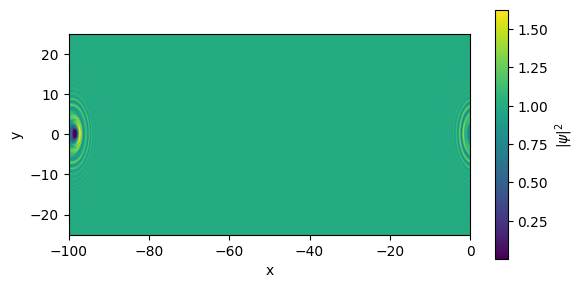

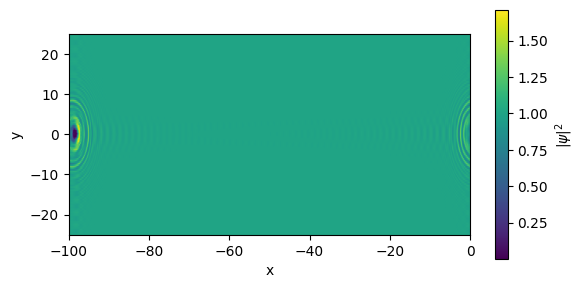

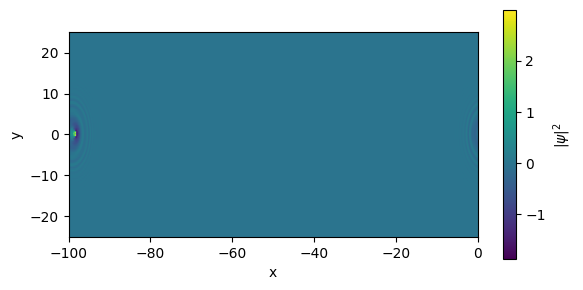

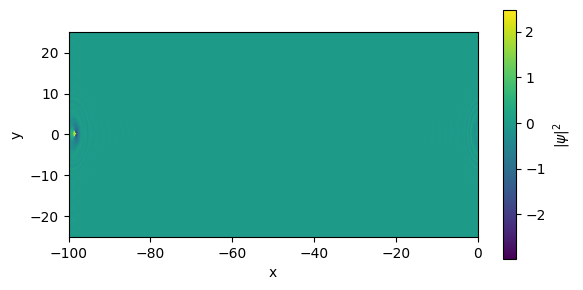

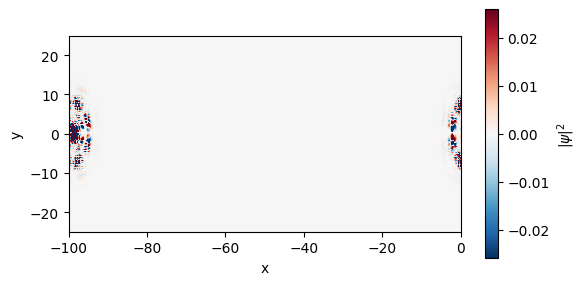

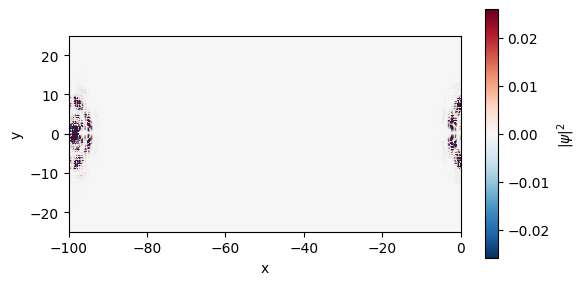

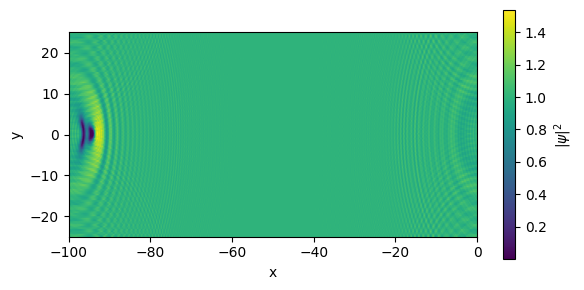

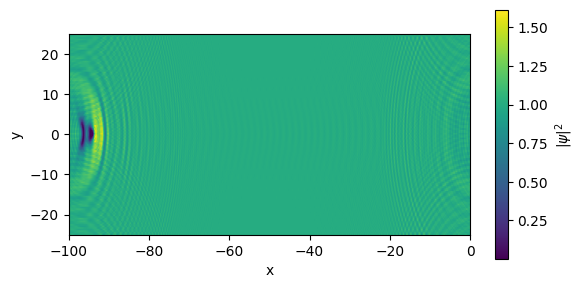

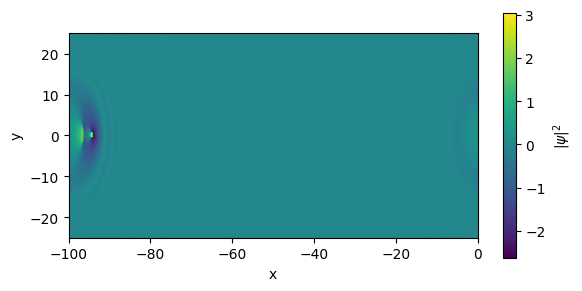

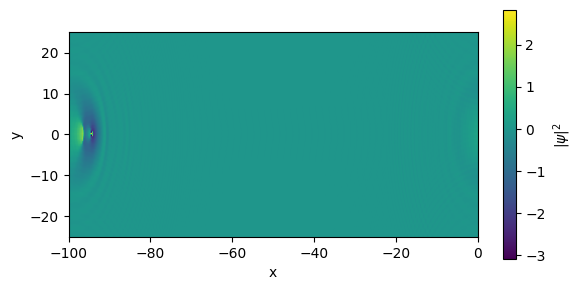

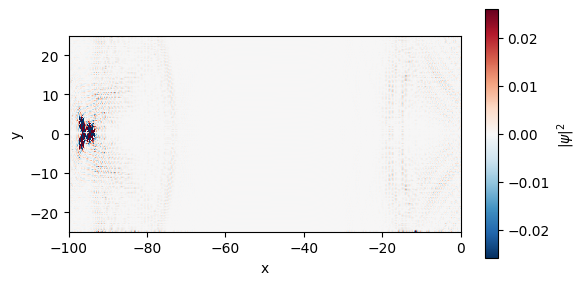

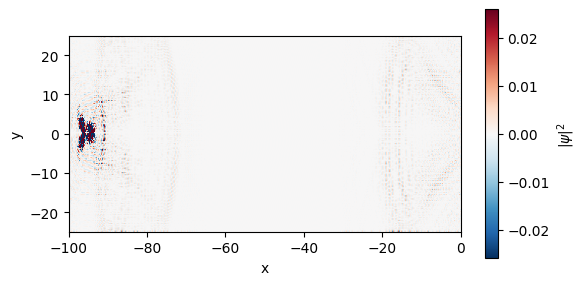

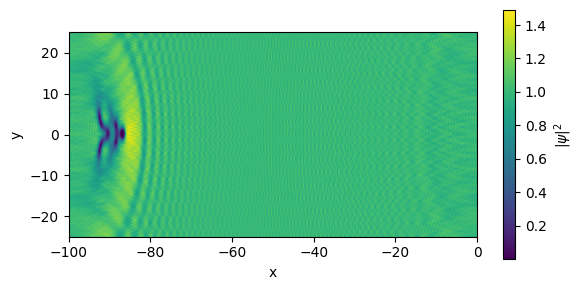

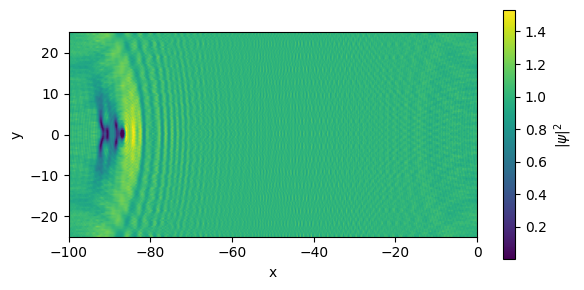

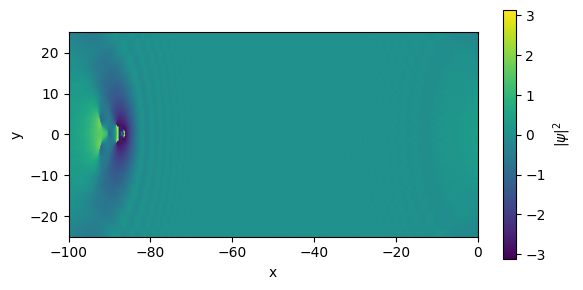

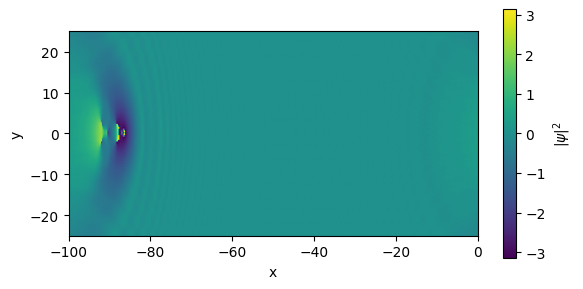

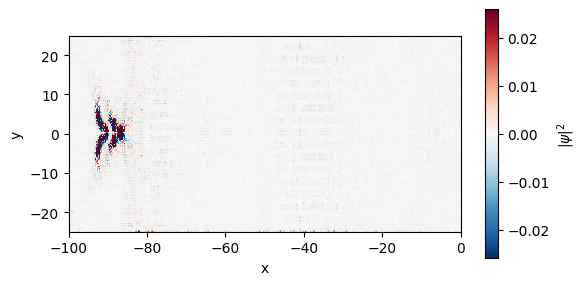

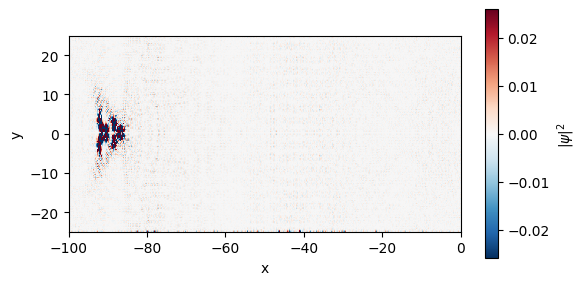

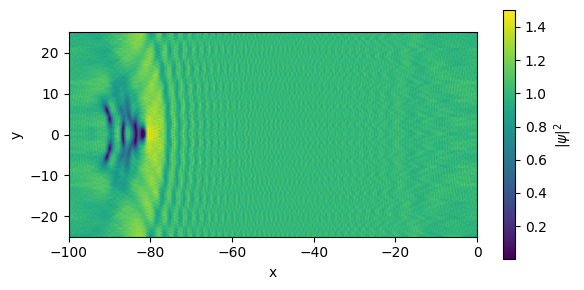

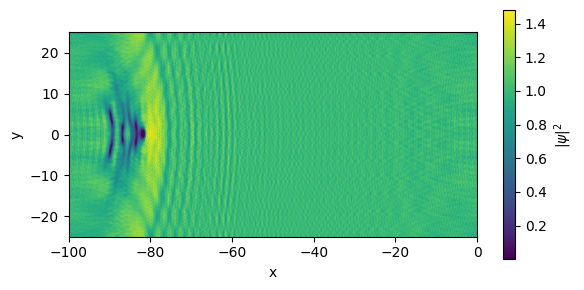

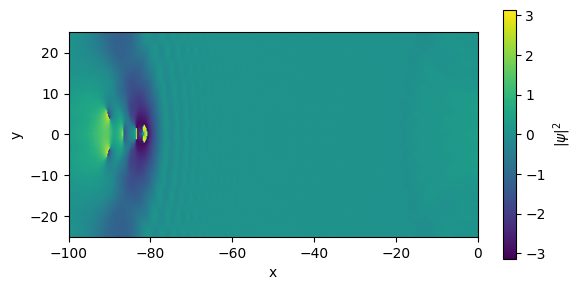

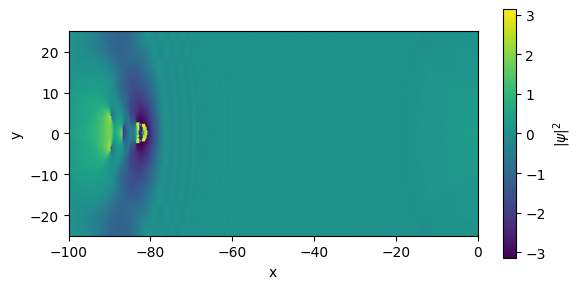

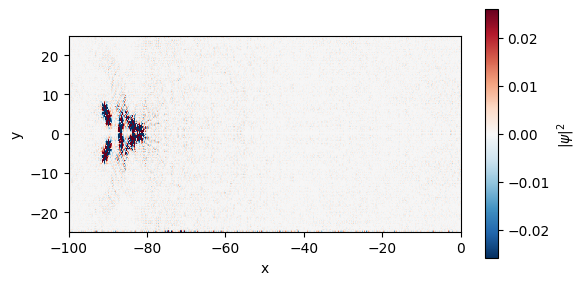

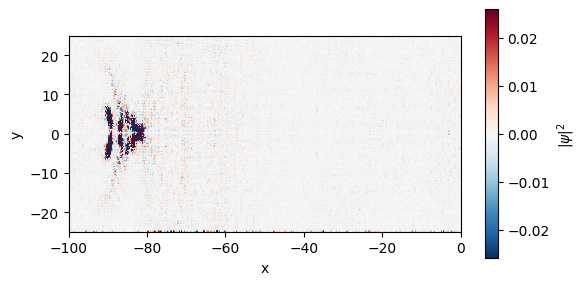

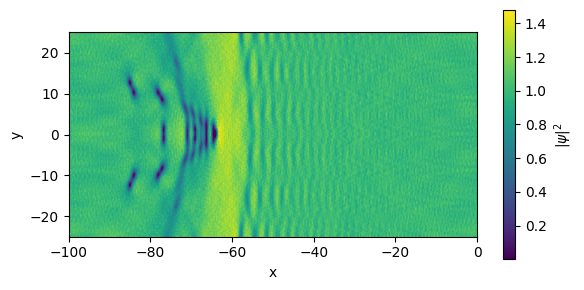

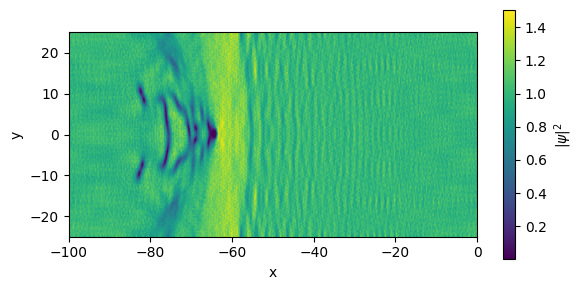

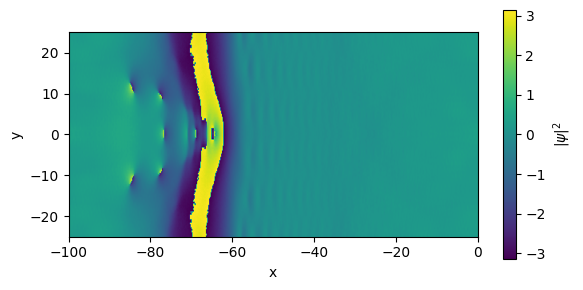

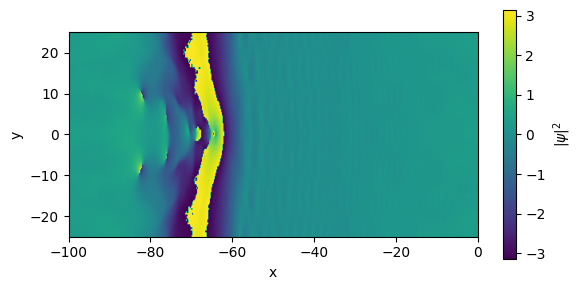

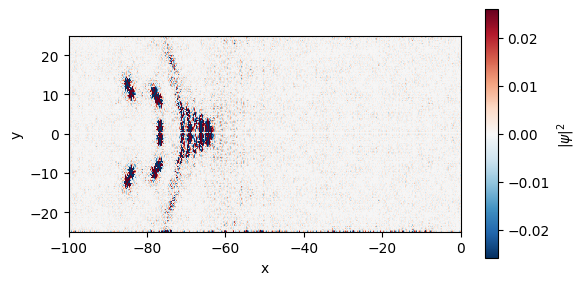

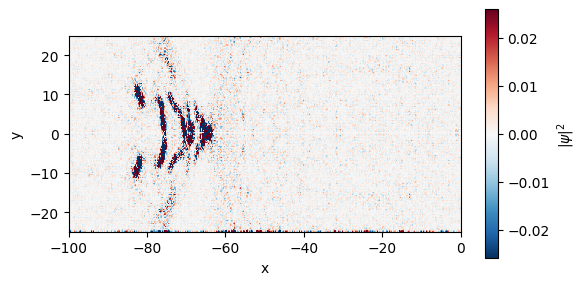

In [ ]:
for t in range(len(show_t)):
    plt.figure(figsize=(6, 3))
    plt.imshow(
        psi0density_history[t].T,
        extent=[-100, 0, -25, 25],
        origin="lower",
        aspect="equal",
        cmap="viridis"
    )
    plt.xlabel("x")
    plt.ylabel("y")
    #plt.title(f"SSFM density, t = {times[t]:.2f}")
    plt.colorbar(label=r"$|\psi|^2$")
    plt.tight_layout()


    plt.figure(figsize=(6, 3))
    plt.imshow(
        psi1density_history[t].T,
        extent=[-100, 0, -25, 25],
        origin="lower",
        aspect="equal",
        cmap="viridis"
    )
    plt.xlabel("x")
    plt.ylabel("y")
    #plt.title(f"filtered-QSSFM density, t = {times[t]:.2f}")
    plt.colorbar(label=r"$|\psi|^2$")
    plt.tight_layout()
    #plt.savefig(f"filtered_qssfm_density_2d_t={t}.png", dpi=300, bbox_inches="tight")
    #plt.show()

    plt.figure(figsize=(6, 3))
    plt.imshow(
        phase0[t].T,
        extent=[-100, 0, -25, 25],
        origin="lower",
        aspect="equal",
        cmap="viridis"
    )
    plt.xlabel("x")
    plt.ylabel("y")
    #plt.title(f"filtered-QSSFM density, t = {times[t]:.2f}")
    plt.colorbar(label=r"$|\psi|^2$")
    plt.tight_layout()
    #plt.savefig(f"filtered_qssfm_density_2d_t={t}.png", dpi=300, bbox_inches="tight")
    #plt.show()

    plt.figure(figsize=(6, 3))
    plt.imshow(
        phase1[t].T,
        extent=[-100, 0, -25, 25],
        origin="lower",
        aspect="equal",
        cmap="viridis"
    )
    plt.xlabel("x")
    plt.ylabel("y")
    #plt.title(f"filtered-QSSFM density, t = {times[t]:.2f}")
    plt.colorbar(label=r"$|\psi|^2$")
    plt.tight_layout()
    #plt.savefig(f"filtered_qssfm_density_2d_t={t}.png", dpi=300, bbox_inches="tight")
    #plt.show()



    q = 0.99
    omg_abs = np.nanpercentile(np.abs(omega0), 100*q)
    vmin, vmax = -omg_abs, omg_abs

    plt.figure(figsize=(6, 3))
    plt.imshow(
        omega0[t].T,
        extent=[-100, 0, -25, 25],
        origin="lower",
        aspect="equal",
        cmap="RdBu_r",
        vmin=-omg_abs,
        vmax=omg_abs
    )
    plt.xlabel("x")
    plt.ylabel("y")
    #plt.title(f"filtered-QSSFM density, t = {times[t]:.2f}")
    plt.colorbar(label=r"$|\psi|^2$")
    plt.tight_layout()
    #plt.savefig(f"filtered_qssfm_density_2d_t={t}.png", dpi=300, bbox_inches="tight")
    #plt.show()


    plt.figure(figsize=(6, 3))
    plt.imshow(
        omega1[t].T,
        extent=[-100, 0, -25, 25],
        origin="lower",
        aspect="equal",
        cmap="RdBu_r",
        vmin=-omg_abs,
        vmax=omg_abs
    )
    plt.xlabel("x")
    plt.ylabel("y")
    #plt.title(f"filtered-QSSFM density, t = {times[t]:.2f}")
    plt.colorbar(label=r"$|\psi|^2$")
    plt.tight_layout()
    #plt.savefig(f"filtered_qssfm_density_2d_t={t}.png", dpi=300, bbox_inches="tight")
    #plt.show()

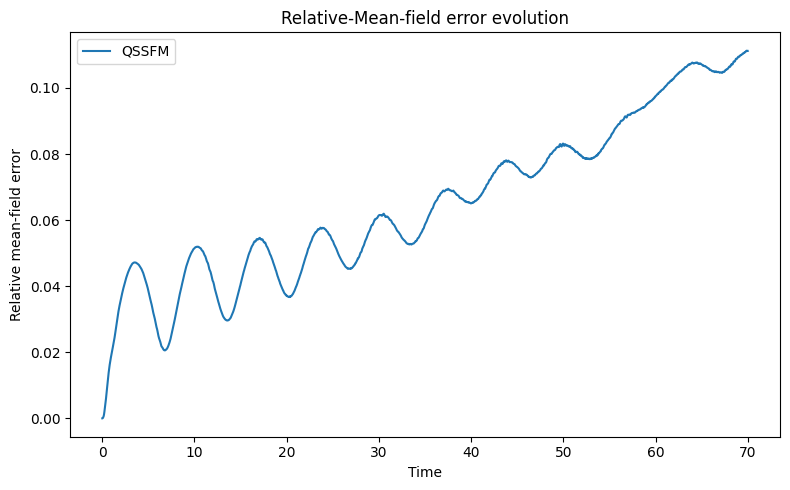

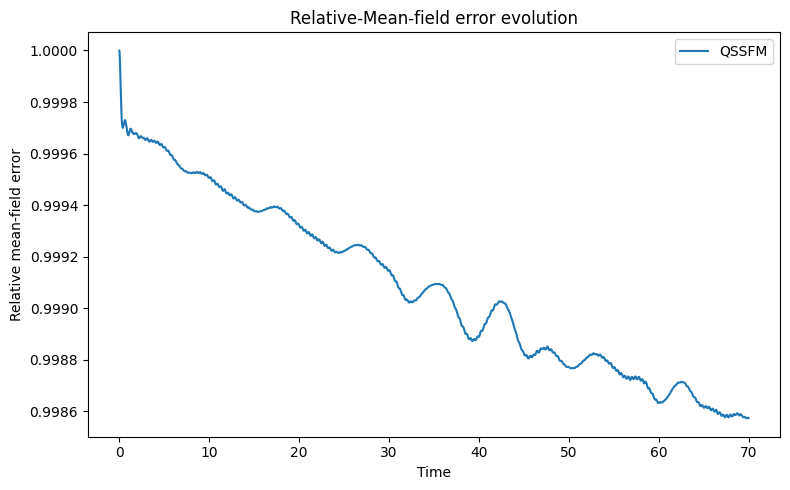

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(times, error_history, label='QSSFM')

plt.xlabel('Time')
plt.ylabel('Relative mean-field error')

plt.legend()
plt.title('Relative-Mean-field error evolution')
plt.tight_layout()
#plt.savefig("mean_field_error.pdf", dpi=300)
plt.show()


plt.figure(figsize=(8,5))
plt.plot(times, eta, label='QSSFM')

plt.xlabel('Time')
plt.ylabel('Relative mean-field error')

plt.legend()
plt.title('Relative-Mean-field error evolution')
plt.tight_layout()
#plt.savefig("mean_field_error.pdf", dpi=300)
plt.show()